# 01 – Data Understanding

## Research Question

Can the physical properties of a star be used to predict whether its orbiting planet is a gas giant?

This project investigates whether stellar characteristics—including effective temperature, radius, metallicity, and distance—contain enough information to distinguish gas giant exoplanets from other planetary types using supervised machine learning.

## Scientific Motivation

Understanding the relationship between stars and their planets is a fundamental question in exoplanet science. Stellar properties influence the conditions under which planetary systems form and evolve, making them valuable predictors of planetary characteristics.

Rather than focusing solely on predictive accuracy, this project also explores the scientific relationships between stellar environments and gas giant occurrence while acknowledging the observational limitations of real astronomical survey data.

## Dataset

The dataset used in this project was obtained from the NASA Exoplanet Archive and contains confirmed exoplanets discovered using multiple observational techniques, including the transit and radial velocity methods. The catalog includes measurements describing planetary orbits, planetary physical properties, stellar characteristics, and system-level information.

This notebook focuses exclusively on understanding the raw dataset before any preprocessing, feature engineering, or machine learning is performed.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [2]:
df = pd.read_csv("../data/raw/exoplanets_raw.csv", comment="#")

print(f"Dataset loaded successfully with {df.shape[0]:,} rows and {df.shape[1]} columns.")

Dataset loaded successfully with 39,954 rows and 50 columns.


In [3]:
df.head()

,pl_name,discoverymethod,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,pl_rade,pl_radeerr1,pl_radeerr2,pl_radelim,pl_msinie,pl_msinieerr1,pl_msinieerr2,pl_msinielim,pl_orbeccen,pl_orbeccenerr1,pl_orbeccenerr2,pl_orbeccenlim,pl_eqt,pl_eqterr1,pl_eqterr2,pl_eqtlim,st_spectype,st_teff,st_tefferr1,st_tefferr2,st_tefflim,st_rad,st_raderr1,st_raderr2,st_radlim,st_met,st_meterr1,st_meterr2,st_metlim,st_lum,st_lumerr1,st_lumerr2,st_lumlim,st_logg,st_loggerr1,st_loggerr2,st_logglim,st_age,st_ageerr1,st_ageerr2,st_agelim,sy_dist,sy_disterr1,sy_disterr2
0,11 Com b,Radial Velocity,323.21000,0.06,-0.05,0.0,NaN,NaN,NaN,NaN,4914.898486,39.092894,-39.728551,0.0,0.238,0.007,-0.007,0.0,NaN,NaN,NaN,NaN,G8 III,4874.0,NaN,NaN,0.0,13.76,2.85,-2.45,0.0,-0.26,0.10,-0.10,0.0,1.97823,0.18002,-0.15868,0.0,2.45,0.08,-0.08,0.0,NaN,NaN,NaN,NaN,93.1846,1.9238,-1.9238
1,11 Com b,Radial Velocity,326.03000,0.32,-0.32,0.0,NaN,NaN,NaN,NaN,6165.600000,476.700000,-476.700000,0.0,0.231,0.005,-0.005,0.0,NaN,NaN,NaN,NaN,G8 III,4742.0,100.0,-100.0,0.0,19.00,2.00,-2.00,0.0,-0.35,0.09,-0.09,0.0,2.24300,0.07100,-0.08500,0.0,2.31,0.10,-0.10,0.0,NaN,NaN,NaN,NaN,93.1846,1.9238,-1.9238
2,11 Com b,Radial Velocity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5434.700000,540.300000,-413.200000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93.1846,1.9238,-1.9238
3,11 UMi b,Radial Velocity,516.21997,3.20,-3.20,0.0,NaN,NaN,NaN,NaN,4684.814200,794.575000,-794.575000,0.0,0.080,0.030,-0.030,0.0,NaN,NaN,NaN,NaN,NaN,4213.0,46.0,-46.0,0.0,29.79,2.84,-2.84,0.0,-0.02,NaN,NaN,0.0,NaN,NaN,NaN,NaN,1.93,0.07,-0.07,0.0,NaN,NaN,NaN,NaN,125.3210,1.9765,-1.9765
4,11 UMi b,Radial Velocity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3432.400000,381.400000,-413.200000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,125.3210,1.9765,-1.9765


In [4]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 39,954
Columns: 50


In [5]:
columns = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values
})

columns

,Column,Data Type
0,pl_name,str
1,discoverymethod,str
2,pl_orbper,float64
3,pl_orbpererr1,float64
4,pl_orbpererr2,float64
5,pl_orbperlim,float64
6,pl_rade,float64
7,pl_radeerr1,float64
8,pl_radeerr2,float64
9,pl_radelim,float64


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39954 entries, 0 to 39953
Data columns (total 50 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          39954 non-null  str    
 1   discoverymethod  39954 non-null  str    
 2   pl_orbper        36595 non-null  float64
 3   pl_orbpererr1    34884 non-null  float64
 4   pl_orbpererr2    34883 non-null  float64
 5   pl_orbperlim     36595 non-null  float64
 6   pl_rade          27540 non-null  float64
 7   pl_radeerr1      26795 non-null  float64
 8   pl_radeerr2      26795 non-null  float64
 9   pl_radelim       30286 non-null  float64
 10  pl_msinie        2731 non-null   float64
 11  pl_msinieerr1    2460 non-null   float64
 12  pl_msinieerr2    2460 non-null   float64
 13  pl_msinielim     2731 non-null   float64
 14  pl_orbeccen      19019 non-null  float64
 15  pl_orbeccenerr1  3945 non-null   float64
 16  pl_orbeccenerr2  3944 non-null   float64
 17  pl_orbeccenlim   21763 

In [7]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing (%)": (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing.sort_values("Missing (%)", ascending=False)

missing.head(20)

,Missing Values,Missing (%)
pl_msinieerr1,37494,93.84
pl_msinieerr2,37494,93.84
pl_eqterr2,37246,93.22
pl_eqterr1,37246,93.22
pl_msinielim,37223,93.16
pl_msinie,37223,93.16
st_spectype,36851,92.23
pl_orbeccenerr2,36010,90.13
pl_orbeccenerr1,36009,90.13
st_lumerr2,35109,87.87


In [8]:
df.isna().sum()

pl_name                0
discoverymethod        0
pl_orbper           3359
pl_orbpererr1       5070
pl_orbpererr2       5071
pl_orbperlim        3359
pl_rade            12414
pl_radeerr1        13159
pl_radeerr2        13159
pl_radelim          9668
pl_msinie          37223
pl_msinieerr1      37494
pl_msinieerr2      37494
pl_msinielim       37223
pl_orbeccen        20935
pl_orbeccenerr1    36009
pl_orbeccenerr2    36010
pl_orbeccenlim     18191
pl_eqt             22419
pl_eqterr1         37246
pl_eqterr2         37246
pl_eqtlim          19675
st_spectype        36851
st_teff             3603
st_tefferr1         4559
st_tefferr2         4819
st_tefflim          3603
st_rad              3412
st_raderr1          9120
st_raderr2          9273
st_radlim           3412
st_met             14928
st_meterr1         15603
st_meterr2         15603
st_metlim          12616
st_lum             30136
st_lumerr1         35054
st_lumerr2         35109
st_lumlim          30136
st_logg             8975


In [9]:
duplicate_planets = df["pl_name"].duplicated().sum()

print(f"Duplicate planet names: {duplicate_planets:,}")

Duplicate planet names: 33,638


In [10]:
df.describe()

,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,pl_rade,pl_radeerr1,pl_radeerr2,pl_radelim,pl_msinie,pl_msinieerr1,pl_msinieerr2,pl_msinielim,pl_orbeccen,pl_orbeccenerr1,pl_orbeccenerr2,pl_orbeccenlim,pl_eqt,pl_eqterr1,pl_eqterr2,pl_eqtlim,st_teff,st_tefferr1,st_tefferr2,st_tefflim,st_rad,st_raderr1,st_raderr2,st_radlim,st_met,st_meterr1,st_meterr2,st_metlim,st_lum,st_lumerr1,st_lumerr2,st_lumlim,st_logg,st_loggerr1,st_loggerr2,st_logglim,st_age,st_ageerr1,st_ageerr2,st_agelim,sy_dist,sy_disterr1,sy_disterr2
count,3.659500e+04,3.488400e+04,3.488300e+04,36595.000000,27540.000000,26795.000000,26795.000000,30286.000000,2731.000000,2460.000000,2460.000000,2731.000000,19019.000000,3945.000000,3944.000000,21763.000000,17535.000000,2708.000000,2708.000000,20279.000000,36351.000000,35395.000000,35135.000000,36351.000000,36542.000000,30834.000000,30681.000000,36542.000000,25026.000000,24351.000000,24351.000000,27338.000000,9818.000000,4900.000000,4845.000000,9818.000000,30979.000000,25521.000000,25520.000000,30979.000000,9834.000000,9375.000000,9375.000000,21214.000000,39100.000000,38237.000000,38237.000000
mean,1.196132e+04,1.382946e+04,-3.259654e+03,-0.000246,5.446621,1.936948,-0.762182,-0.000132,754.363525,95.260145,-86.730985,0.001831,0.048064,0.061649,-0.050104,0.030005,881.214693,32.645159,-31.840694,0.000148,5455.549110,115.601809,-117.488462,0.000028,1.150763,0.201055,-0.125947,0.000055,-0.021687,0.141284,-0.152267,-0.000183,-0.155455,0.037596,-0.041046,0.000204,4.411590,0.099101,-0.152428,-0.000194,4.617140,2.394776,-1.958636,-0.007354,721.138011,36.958126,-38.638563
std,2.102652e+06,2.516611e+06,5.366524e+05,0.020245,71.212750,74.735067,18.890319,0.014075,1212.893344,586.842737,561.822040,0.057388,0.127527,0.066200,0.051950,0.183579,429.507530,49.668790,49.506257,0.012162,996.227806,84.735135,86.420840,0.005245,1.779156,0.862715,0.600472,0.007398,0.227038,0.097299,0.104739,0.018144,0.727570,0.039631,0.056010,0.014272,0.301762,0.110765,0.138738,0.016069,3.480304,1.809221,1.338874,0.102496,834.733135,158.350847,184.599385
min,9.070629e-02,0.000000e+00,-1.000000e+08,-1.000000,0.270000,0.000000,-1916.293000,-1.000000,0.015000,0.000000,-24965.546500,-1.000000,-0.011000,0.000000,-0.703000,-1.000000,34.000000,0.000000,-1217.000000,0.000000,415.000000,0.000000,-6064.900000,0.000000,0.012100,0.000000,-73.630000,0.000000,-2.500000,0.000000,-1.000000,-1.000000,-4.660000,0.000170,-1.431360,0.000000,0.100000,0.000000,-3.510000,-1.000000,0.000000,0.000000,-18.000000,-1.000000,1.301190,0.000340,-2900.000000
25%,4.362737e+00,8.009250e-06,-2.006000e-04,0.000000,1.560000,0.158000,-0.460000,0.000000,21.606166,2.692440,-63.565681,0.000000,0.000000,0.016000,-0.070000,0.000000,568.000000,12.000000,-36.000000,0.000000,5090.000000,76.000000,-146.000000,0.000000,0.785000,0.039000,-0.110000,0.000000,-0.148900,0.060000,-0.260000,0.000000,-0.467370,0.015287,-0.049770,0.000000,4.310000,0.033000,-0.260000,0.000000,2.100000,0.940000,-2.900000,0.000000,268.685000,1.909500,-20.190000
50%,1.030066e+01,3.824000e-05,-3.829000e-05,0.000000,2.308000,0.362309,-0.220000,0.000000,324.186600,19.069704,-19.069704,0.000000,0.000000,0.040000,-0.035000,0.000000,798.000000,21.000000,-20.000000,0.000000,5609.000000,113.000000,-117.000000,0.000000,0.950000,0.078000,-0.062000,0.000000,-0.000600,0.120000,-0.140000,0.000000,-0.086120,0.023155,-0.022600,0.000000,4.467000,0.068274,-0.105000,0.000000,4.000000,2.000000,-1.790000,0.000000,573.000000,7.271500,-7.189000
75%,2.644435e+01,2.012000e-04,-8.041200e-06,0.000000,3.300000,0.790000,-0.120000,0.000000,890.261000,63.566000,-2.542627,0.000000,0.000000,0.081000,-0.014000,0.000000,1106.000000,37.000000,-12.000000,0.000000,5949.000000,153.000000,-75.000000,0.000000,1.212000,0.287000,-0.036000,0.000000,0.120000,0.220000,-0.060000,0.000000,0.304100,0.048760,-0.015400,0.000000,4.568000,0.110000,-0.057000,0.000000,6.200000,3.605000,-0.860000,0.000000,928.989000,20.856000,-1.896000
max,4.020000e+08,4.700000e+08,0.000000e+00,1.000000

## Initial Data Quality Observations

Several characteristics of the raw dataset are immediately apparent:

- Many astrophysical variables contain substantial missing data because different exoplanet detection methods measure different physical properties.
- Some confirmed exoplanets appear multiple times, reflecting updated measurements or multiple published observations rather than data entry errors.
- Planetary and stellar measurements span several orders of magnitude, suggesting that some variables are highly skewed.
- These observations indicate that careful preprocessing will be required before constructing machine learning models.

At this stage, no preprocessing has been performed. The objective is only to understand the structure and limitations of the raw NASA Exoplanet Archive.

In [11]:
discovery_counts = (
    df["discoverymethod"]
    .value_counts()
    .sort_values(ascending=False)
)

discovery_counts

discoverymethod
Transit                          35795
Radial Velocity                   2938
Microlensing                       803
Imaging                            187
Transit Timing Variations          162
Eclipse Timing Variations           26
Orbital Brightness Modulation       21
Pulsar Timing                       13
Astrometry                           6
Pulsation Timing Variations          2
Disk Kinematics                      1
Name: count, dtype: int64

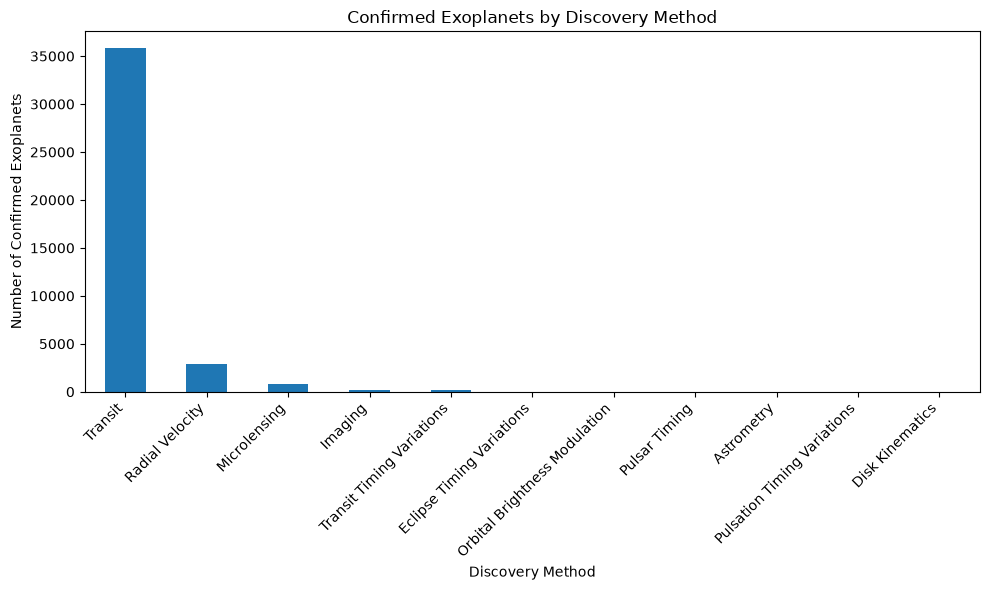

In [12]:
plt.figure(figsize=(10, 6))

discovery_counts.plot(kind="bar")

plt.title("Confirmed Exoplanets by Discovery Method")
plt.xlabel("Discovery Method")
plt.ylabel("Number of Confirmed Exoplanets")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Interpretation

The majority of confirmed exoplanets in this dataset were discovered using the Transit method, followed by the Radial Velocity method.

This is an important characteristic of the dataset because each detection technique measures different physical quantities.

For example:

- Transit observations directly measure how much starlight is blocked, making planet radius relatively easy to estimate.
- Radial velocity observations measure the motion of the host star, allowing estimates of planetary mass rather than radius.
- Imaging and microlensing detect planets through completely different physical mechanisms and therefore contribute different types of measurements.

As a result, missing values in this dataset are expected and are largely driven by observational limitations rather than data quality problems.

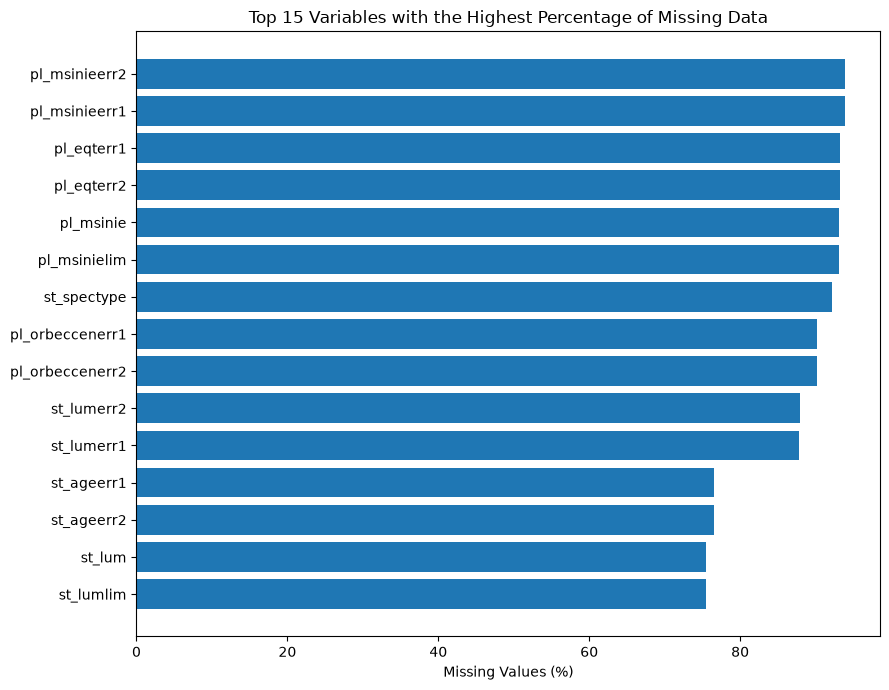

In [13]:
missing_plot = (
    missing[missing["Missing (%)"] > 0]
    .head(15)
    .sort_values("Missing (%)")
)

plt.figure(figsize=(9, 7))

plt.barh(
    missing_plot.index,
    missing_plot["Missing (%)"]
)

plt.xlabel("Missing Values (%)")
plt.title("Top 15 Variables with the Highest Percentage of Missing Data")

plt.tight_layout()
plt.show()

## Interpretation

Several planetary and stellar variables contain a substantial proportion of missing observations.

Rather than indicating poor data quality, these missing values primarily reflect the limitations of astronomical observations. Certain properties can only be measured when specific observational conditions are met or when a planet has been detected using a particular method.

This means that missing values are unlikely to be completely random, an important consideration for both preprocessing and model interpretation later in the project.

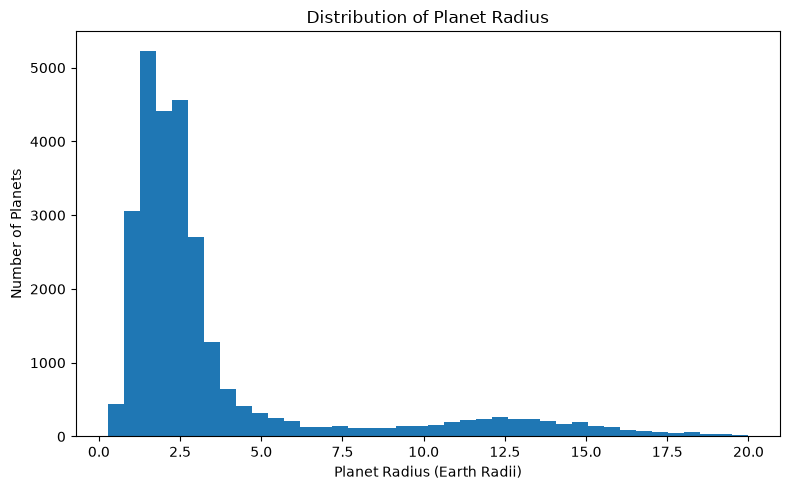

In [14]:
radius_vis = df[
    (df["pl_rade"].notna()) &
    (df["pl_rade"] <= 20)
]

plt.figure(figsize=(8,5))

plt.hist(
    radius_vis["pl_rade"],
    bins=40
)

plt.title("Distribution of Planet Radius")
plt.xlabel("Planet Radius (Earth Radii)")
plt.ylabel("Number of Planets")

plt.tight_layout()
plt.show()

## Interpretation

Most confirmed exoplanets in the dataset have radii below approximately 4 Earth radii, while progressively fewer large planets are observed.

A small number of extremely large planets create a strongly right-skewed distribution. These outliers have been excluded from this visualization only to improve readability; they remain part of the dataset for later analysis.

The observed distribution reflects both astrophysical processes and observational bias, since larger planets are generally easier to detect than smaller ones.

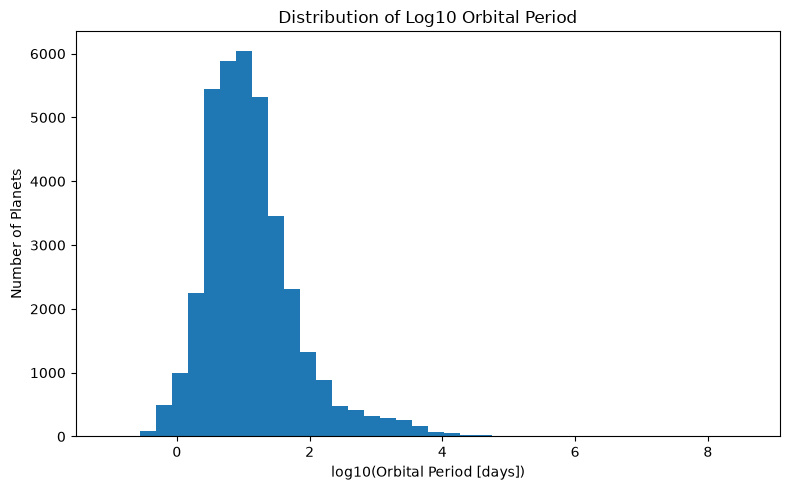

In [ ]:
import numpy as np

orbital_period = df["pl_orbper"].dropna()

plt.figure(figsize=(8,5))

plt.hist(
    np.log10(orbital_period),
    bins=40
)

plt.title("Distribution of Exoplanet Orbital Periods")
plt.xlabel("log₁₀(Orbital Period in Days)")
plt.ylabel("Number of Planets")

plt.tight_layout()
plt.show()

## Interpretation

Exoplanet orbital periods span many orders of magnitude, ranging from less than one day to several million days. Plotting the logarithm of the orbital period provides a clearer view of the overall distribution by reducing the influence of extreme values.

Most confirmed exoplanets in the dataset have relatively short orbital periods. This pattern is influenced by observational selection effects, as planets with shorter periods transit their host stars more frequently and therefore have a higher probability of being detected by transit surveys.

The broad range of orbital periods also highlights the diversity of planetary systems represented in the NASA Exoplanet Archive.

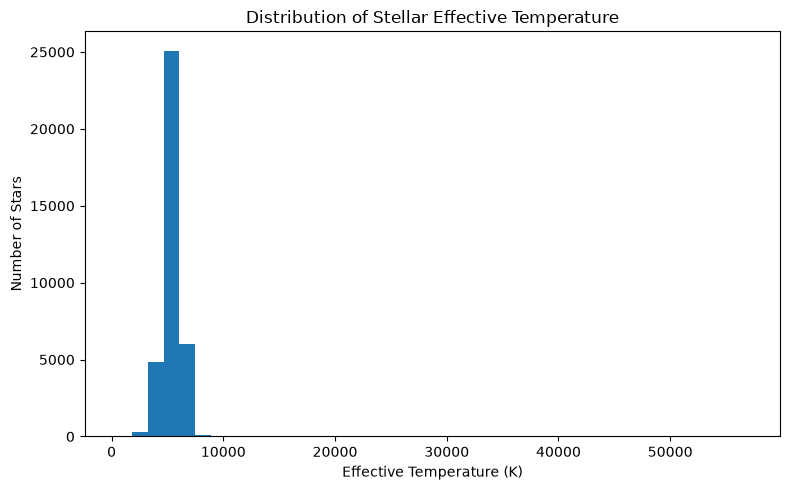

In [17]:
stellar_temp = df[df["st_teff"].notna()]

plt.figure(figsize=(8,5))

plt.hist(
    stellar_temp["st_teff"],
    bins=40
)

plt.title("Distribution of Stellar Effective Temperature")
plt.xlabel("Effective Temperature (K)")
plt.ylabel("Number of Stars")

plt.tight_layout()
plt.show()

## Interpretation

Most host stars have effective temperatures similar to F-, G-, and K-type stars, with comparatively fewer very cool or very hot stars represented.

This reflects both the stellar population observed by exoplanet surveys and the greater observational challenges associated with detecting planets around certain types of stars.

### Research Question

Are there observable relationships between key planetary and stellar properties that may influence later machine learning modeling?

In [23]:
selected_features = {
    "pl_rade": "Planet Radius",
    "pl_orbper": "Orbital Period",
    "pl_eqt": "Equilibrium Temp",
    "st_teff": "Stellar Temp",
    "st_rad": "Stellar Radius",
    "st_met": "Metallicity",
    "st_age": "Stellar Age",
    "sy_dist": "Distance"
}

correlation = df[list(selected_features.keys())].corr()

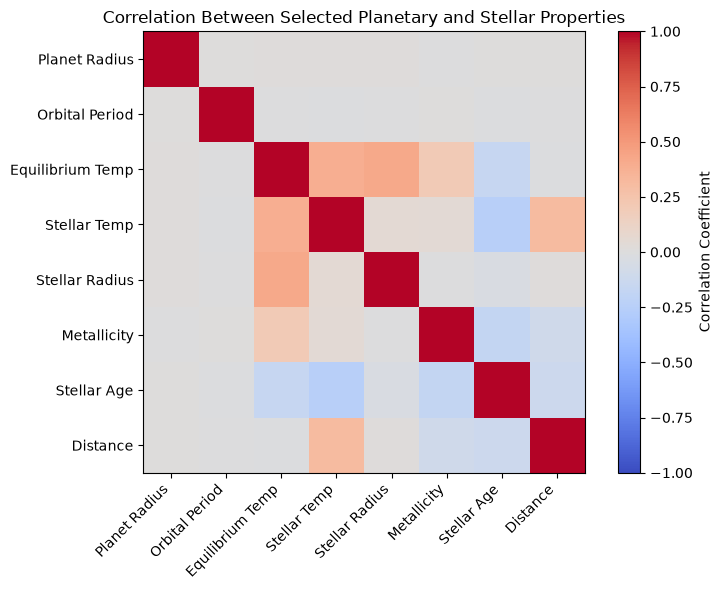

In [25]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlation Coefficient")

labels = list(selected_features.values())

plt.xticks(
    range(len(labels)),
    labels,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(labels)),
    labels
)

plt.title("Correlation Between Selected Planetary and Stellar Properties")

plt.tight_layout()
plt.show()

### Interpretation

Most feature pairs exhibit relatively weak linear correlations, indicating that they capture different aspects of planetary systems rather than providing redundant information.

A few moderate relationships are visible. For example, stellar radius and stellar effective temperature show some association, which is expected because both describe fundamental properties of the host star.

Overall, the absence of strong correlations among most variables suggests that each feature may contribute unique information during machine learning model development.

### Scientific Implication

The weak correlations observed among most variables suggest that predicting whether a planet is a gas giant is unlikely to depend on a single stellar property. Instead, the relationship is expected to arise from the combined influence of multiple stellar characteristics.

This supports the use of multivariable machine learning models, which can learn complex relationships that are difficult to identify through simple pairwise comparisons alone.

## Dataset Strengths

This dataset provides several advantages for investigating relationships between stellar properties and gas giant occurrence:

- **Large sample size:** Nearly 40,000 confirmed exoplanet observations provide substantial statistical power for exploratory analysis and machine learning.
- **Real observational data:** The dataset originates from the NASA Exoplanet Archive, making the project representative of real astronomical research rather than synthetic examples.
- **Rich feature set:** Measurements describing planetary characteristics, stellar properties, and planetary systems enable both astrophysical interpretation and predictive modeling.
- **Multiple discovery techniques:** Combining observations from several detection methods increases the diversity of planetary systems represented in the dataset.

## Dataset Limitations

Several limitations should be considered when interpreting analyses based on this dataset:

- **Observational selection effects:** Larger planets and planets with shorter orbital periods are generally easier to detect, meaning the observed sample is not fully representative of all planetary systems.
- **Missing values are not random:** Many measurements are unavailable because different discovery techniques measure different physical quantities. As a result, missing data reflect observational constraints rather than random omissions.
- **Repeated observations:** Some confirmed exoplanets appear multiple times because the NASA archive stores updated measurements from different publications.
- **Measurement uncertainty:** Astronomical observations contain uncertainties that vary depending on the detection method, instrument sensitivity, and observing conditions.

These limitations are characteristic of real astronomical survey data and should be considered throughout subsequent preprocessing and model interpretation.

## Key Scientific Findings

Analysis of the raw NASA Exoplanet Archive reveals several important characteristics:

- The **Transit** method is the dominant discovery technique represented in the dataset.
- Planet radii are strongly right-skewed, with most confirmed exoplanets having relatively small radii and a small number of extreme outliers.
- Orbital periods span several orders of magnitude, illustrating the remarkable diversity of planetary systems.
- Host stars are concentrated within a relatively narrow range of effective temperatures, broadly corresponding to Sun-like stars.
- Missing values primarily arise from observational limitations rather than data quality issues.
- Correlations among stellar and planetary variables are generally modest, suggesting that multiple stellar properties may collectively contribute to predicting gas giant occurrence.

## Transition to Data Preprocessing

The exploratory analysis performed in this notebook provides an overview of the raw NASA Exoplanet Archive and highlights several important characteristics, including observational biases, missing data patterns, and the diversity of planetary systems.

The next notebook focuses on constructing a machine learning dataset by selecting scientifically meaningful variables, addressing duplicate observations, handling missing values, engineering the target variable, and preparing the data for predictive modeling while minimizing the risk of data leakage.